# Spectral Clustering Algorithms Implementation

This notebook implements the two spectral clustering algorithms from the provided image:
1. Algorithm 1: Random Walk Laplacian Spectral Clustering
2. Algorithm 2: Symmetric Normalized Laplacian Spectral Clustering


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import os


In [2]:
# Load the EU Air Transportation Network data
file_path = 'data/EU_air'

# Read node positions
node_pos = {}
with open(f"{file_path}/EUAirTransportation_nodes.txt", "r") as f:
    next(f)  # Skip header
    for line in f:
        parts = line.strip().split()
        node_id = parts[0]
        lon = float(parts[-2])
        lat = float(parts[-1])
        node_pos[node_id] = (lon, lat)

# Parse edges by layer
layer_edges = {}
with open(f"{file_path}/EUAirTransportation_multiplex.edges", "r") as f:
    for line in f:
        parts = line.strip().split()
        layer = parts[0]
        node1 = parts[1]
        node2 = parts[2]
        layer_edges.setdefault(layer, []).append((node1, node2))

# Create a combined graph for all layers
G = nx.Graph()
for layer, edges in layer_edges.items():
    G.add_edges_from(edges, layer=layer)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Number of layers: {len(layer_edges)}")


Graph has 417 nodes and 2953 edges
Number of layers: 37


In [3]:
# Create adjacency matrix and degree matrix
nodes = list(G.nodes())
n = len(nodes)
node_to_idx = {node: i for i, node in enumerate(nodes)}

# Adjacency matrix W
W = nx.adjacency_matrix(G, nodelist=nodes).toarray()

# Degree matrix D
degrees = np.sum(W, axis=1)
D = np.diag(degrees)

# Laplacian matrix L = D - W
L = D - W

print(f"Adjacency matrix shape: {W.shape}")
print(f"Degree matrix shape: {D.shape}")
print(f"Laplacian matrix shape: {L.shape}")


Adjacency matrix shape: (417, 417)
Degree matrix shape: (417, 417)
Laplacian matrix shape: (417, 417)


## Algorithm 1: Random Walk Laplacian Spectral Clustering

Following the algorithm from the image:
1. Compute L_rw = D^-1 L
2. Find k smallest eigenvalues and eigenvectors
3. Form node points x_i = (u_1i, ..., u_ki)
4. Cluster points using k-means
5. Output communities


In [4]:
def random_walk_spectral_clustering(W, k):
    """
    Algorithm 1: Random Walk Laplacian Spectral Clustering
    
    Args:
        W: Weight matrix (adjacency matrix)
        k: Number of clusters
    
    Returns:
        communities: List of lists, each containing node indices for each community
    """
    n = W.shape[0]
    
    # Step 1: Compute L_rw = D^-1 L
    degrees = np.sum(W, axis=1)
    D_inv = np.diag(1.0 / degrees)
    L = np.diag(degrees) - W
    L_rw = D_inv @ L
    
    # Step 2: Find k smallest eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(L_rw)
    
    # Get k smallest eigenvalues and their eigenvectors
    idx = np.argsort(eigenvalues)[:k]
    U = eigenvectors[:, idx]  # Shape: (n, k)
    
    # Step 3: Form node points x_i = (u_1i, ..., u_ki)
    X = U  # Each row is a k-dimensional point for a node
    
    # Step 4: Cluster points using k-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    # Step 5: Output communities
    communities = [[] for _ in range(k)]
    for i, label in enumerate(cluster_labels):
        communities[label].append(i)
    
    return communities, eigenvalues[idx], U


## Algorithm 2: Symmetric Normalized Laplacian Spectral Clustering

Following the algorithm from the image:
1. Compute L_sym = D^-1/2 L D^-1/2
2. Find k smallest eigenvalues and eigenvectors
3. Form node points x_i = (u_1i, ..., u_ki)
4. Normalize points y_i = x_i / ||x_i||
5. Cluster normalized points using k-means
6. Output communities


In [5]:
def symmetric_normalized_spectral_clustering(W, k):
    """
    Algorithm 2: Symmetric Normalized Laplacian Spectral Clustering
    
    Args:
        W: Weight matrix (adjacency matrix)
        k: Number of clusters
    
    Returns:
        communities: List of lists, each containing node indices for each community
    """
    n = W.shape[0]
    
    # Step 1: Compute L_sym = D^-1/2 L D^-1/2
    degrees = np.sum(W, axis=1)
    D_sqrt_inv = np.diag(1.0 / np.sqrt(degrees))
    L = np.diag(degrees) - W
    L_sym = D_sqrt_inv @ L @ D_sqrt_inv
    
    # Step 2: Find k smallest eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(L_sym)
    
    # Get k smallest eigenvalues and their eigenvectors
    idx = np.argsort(eigenvalues)[:k]
    U = eigenvectors[:, idx]  # Shape: (n, k)
    
    # Step 3: Form node points x_i = (u_1i, ..., u_ki)
    X = U  # Each row is a k-dimensional point for a node
    
    # Step 4: Normalize points y_i = x_i / ||x_i||
    Y = normalize(X, norm='l2', axis=1)
    
    # Step 5: Cluster normalized points using k-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(Y)
    
    # Step 6: Output communities
    communities = [[] for _ in range(k)]
    for i, label in enumerate(cluster_labels):
        communities[label].append(i)
    
    return communities, eigenvalues[idx], U, Y


## Visualization Functions

Using the improved plot_communities function


In [6]:
def plot_communities(G, community_of, node_pos=None, title="Communities on graph",
                     show_labels=False, edge_alpha=0.15, node_size=18):
    """
    Plot G with nodes colored by community_of[node].
    """

    nodes = list(G.nodes())

    if node_pos is None:
        pos = nx.spring_layout(G, seed=42)
    else:
        pos = node_pos

    nodes_with_pos = [u for u in nodes if u in pos]
    if not nodes_with_pos:
        raise ValueError("No nodes have positions. Provide a valid node_pos.")

    labels = np.array([community_of.get(u, -1) for u in nodes_with_pos])  # -1 for unknown
    known_mask = labels >= 0
    unknown_mask = ~known_mask

    unique_comms = sorted(np.unique(labels[known_mask]))
    comm_to_idx = {c: i for i, c in enumerate(unique_comms)}
    mapped = np.array([comm_to_idx[c] if c in comm_to_idx else -1 for c in labels])

    bright_colors = [
        "#e41a1c", 
        "#377eb8",  
        "#4daf4a",  
        "#984ea3",  
        "#ff7f00",  
        "#ffff33",  
        "#0a0a0a", 
    ]
    cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback
    color_list = bright_colors if len(unique_comms) <= len(bright_colors) else cmap.colors

    plt.figure(figsize=(10, 8))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v) for u, v in G.edges() if u in pos and v in pos],
        width=0.4,
        alpha=edge_alpha,
        edge_color="gray",
    )

    xs = [pos[u][0] for u in nodes_with_pos]
    ys = [pos[u][1] for u in nodes_with_pos]

    if known_mask.any():
        plt.scatter(
            np.array(xs)[known_mask],
            np.array(ys)[known_mask],
            c=[color_list[i % len(color_list)] for i in mapped[known_mask]],
            s=node_size,
            alpha=0.95,
        )

    if unknown_mask.any():
        plt.scatter(
            np.array(xs)[unknown_mask],
            np.array(ys)[unknown_mask],
            c="lightgray",
            s=node_size,
            alpha=0.9,
            label="unlabeled",
        )

    if show_labels:
        for u in nodes_with_pos:
            x, y = pos[u]
            plt.text(x, y, str(u), fontsize=6, ha="center", va="center")

    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=6,
               label=f"c={c}", markerfacecolor=color_list[i % len(color_list)],
               markeredgecolor="none")
        for i, c in enumerate(unique_comms)
    ]
    if unknown_mask.any():
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=6,
                              label="unlabeled", markerfacecolor="lightgray",
                              markeredgecolor="none"))
    if handles:
        plt.legend(handles=handles, title="Communities", loc="best", frameon=True)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [7]:
def plot_communities_force_directed(G, community_of, title="Force-Directed Communities", 
                                   show_labels=False, edge_alpha=0.15, node_size=18, 
                                   iterations=100, seed=42):
    """
    Plot G with nodes colored by community_of[node] using force-directed layout.
    """
    nodes = list(G.nodes())
    
    # Use force-directed layout with default parameters (like in laplacian_comparison)
    pos = nx.spring_layout(G, seed=seed)
    
    labels = np.array([community_of.get(u, -1) for u in nodes])  # -1 for unknown
    known_mask = labels >= 0
    unknown_mask = ~known_mask
    
    unique_comms = sorted(np.unique(labels[known_mask]))
    comm_to_idx = {c: i for i, c in enumerate(unique_comms)}
    mapped = np.array([comm_to_idx[c] if c in comm_to_idx else -1 for c in labels])
    
    bright_colors = [
        "#e41a1c", 
        "#377eb8",  
        "#4daf4a",  
        "#984ea3",  
        "#ff7f00",  
        "#ffff33",  
        "#0a0a0a", 
    ]
    cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback
    color_list = bright_colors if len(unique_comms) <= len(bright_colors) else cmap.colors
    
    plt.figure(figsize=(12, 10))
    
    # Draw edges
    nx.draw_networkx_edges(
        G,
        pos,
        width=0.3,
        alpha=edge_alpha,
        edge_color="gray",
    )
    
    # Draw nodes
    xs = [pos[u][0] for u in nodes]
    ys = [pos[u][1] for u in nodes]
    
    if known_mask.any():
        plt.scatter(
            np.array(xs)[known_mask],
            np.array(ys)[known_mask],
            c=[color_list[i % len(color_list)] for i in mapped[known_mask]],
            s=node_size,
            alpha=0.95,
        )
    
    if unknown_mask.any():
        plt.scatter(
            np.array(xs)[unknown_mask],
            np.array(ys)[unknown_mask],
            c="lightgray",
            s=node_size,
            alpha=0.9,
            label="unlabeled",
        )
    
    if show_labels:
        for u in nodes:
            x, y = pos[u]
            plt.text(x, y, str(u), fontsize=6, ha="center", va="center")
    
    # Create legend
    handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=8,
               label=f"Community {c}", markerfacecolor=color_list[i % len(color_list)],
               markeredgecolor="none")
        for i, c in enumerate(unique_comms)
    ]
    if unknown_mask.any():
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=8,
                              label="unlabeled", markerfacecolor="lightgray",
                              markeredgecolor="none"))
    if handles:
        plt.legend(handles=handles, title="Communities", loc="best", frameon=True)
    
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def visualize_communities_force_directed(G, communities, title, method_name):
    """
    Wrapper function to use force-directed plot_communities with the old interface
    """
    nodes = list(G.nodes())
    community_of = communities_to_dict(communities, nodes)
    
    plot_communities_force_directed(G, community_of, title)
    
    # Print community sizes
    print(f"Community sizes for {method_name}:")
    for i, community in enumerate(communities):
        print(f"  Community {i+1}: {len(community)} nodes")
    print()


In [8]:
def communities_to_dict(communities, nodes):
    """
    Convert communities list to community_of dictionary format
    """
    community_of = {}
    for i, community in enumerate(communities):
        for node_idx in community:
            node_id = nodes[node_idx]
            community_of[node_id] = i
    return community_of

def visualize_communities_with_plot(G, communities, node_pos, title, method_name):
    """
    Wrapper function to use plot_communities with the old interface
    """
    nodes = list(G.nodes())
    community_of = communities_to_dict(communities, nodes)
    
    plot_communities(G, community_of, node_pos, title)
    
    # Print community sizes
    print(f"Community sizes for {method_name}:")
    for i, community in enumerate(communities):
        print(f"  Community {i+1}: {len(community)} nodes")
    print()


## K Selection Method

Using curvature-based method for selecting optimal K


In [9]:
def pick_k_by_curvature(eigvals, num_cc, return_debug=False):
    """
    Pick K using the curvature (second difference) elbow on the ascending spectrum.
    eigvals : ascending eigenvalues (1D array)
    num_cc  : number of connected components (zeros block size)

    Returns:
      K  (int), and optionally a debug dict.
    """
    lam = np.asarray(eigvals, dtype=float)
    n = lam.size
    start = int(num_cc)

    tail = lam[start:]
    if tail.size < 3:
        gaps = np.diff(tail)
        K = start + (np.argmax(gaps) + 1 if gaps.size else 1)
        if return_debug:
            return int(K), {"start": start, "method": "fallback_gap", "gaps": gaps}
        return int(K)

    second_diff = tail[2:] - 2*tail[1:-1] + tail[:-2]
    elbow_in_tail = int(np.argmax(second_diff)) + 1 
    K = start + elbow_in_tail

    if return_debug:
        return int(K), {
            "start": start,
            "second_diff": second_diff,
            "elbow_in_tail": elbow_in_tail,
            "K": int(K),
        }
    return int(K)

def find_optimal_k_curvature(W):
    """
    Find optimal k using curvature method for both Laplacians
    """
    # Compute both Laplacians
    degrees = np.sum(W, axis=1)
    D_inv = np.diag(1.0 / degrees)
    D_sqrt_inv = np.diag(1.0 / np.sqrt(degrees))
    L = np.diag(degrees) - W
    
    L_rw = D_inv @ L
    L_sym = D_sqrt_inv @ L @ D_sqrt_inv
    
    # Get eigenvalues for both
    eigenvals_rw, _ = np.linalg.eig(L_rw)
    eigenvals_sym, _ = np.linalg.eigh(L_sym)
    
    # Sort eigenvalues
    eigenvals_rw = np.sort(eigenvals_rw)
    eigenvals_sym = np.sort(eigenvals_sym)
    
    # Count connected components (number of zero eigenvalues)
    num_cc_rw = np.sum(np.abs(eigenvals_rw) < 1e-10)
    num_cc_sym = np.sum(np.abs(eigenvals_sym) < 1e-10)
    
    # Use curvature method to find optimal k
    k_rw, debug_rw = pick_k_by_curvature(eigenvals_rw, num_cc_rw, return_debug=True)
    k_sym, debug_sym = pick_k_by_curvature(eigenvals_sym, num_cc_sym, return_debug=True)
    
    return k_rw, k_sym, eigenvals_rw, eigenvals_sym, debug_rw, debug_sym


Optimal k for Random Walk Laplacian: 7
Optimal k for Symmetric Normalized Laplacian: 7
Number of connected components (RW): 1
Number of connected components (SYM): 1


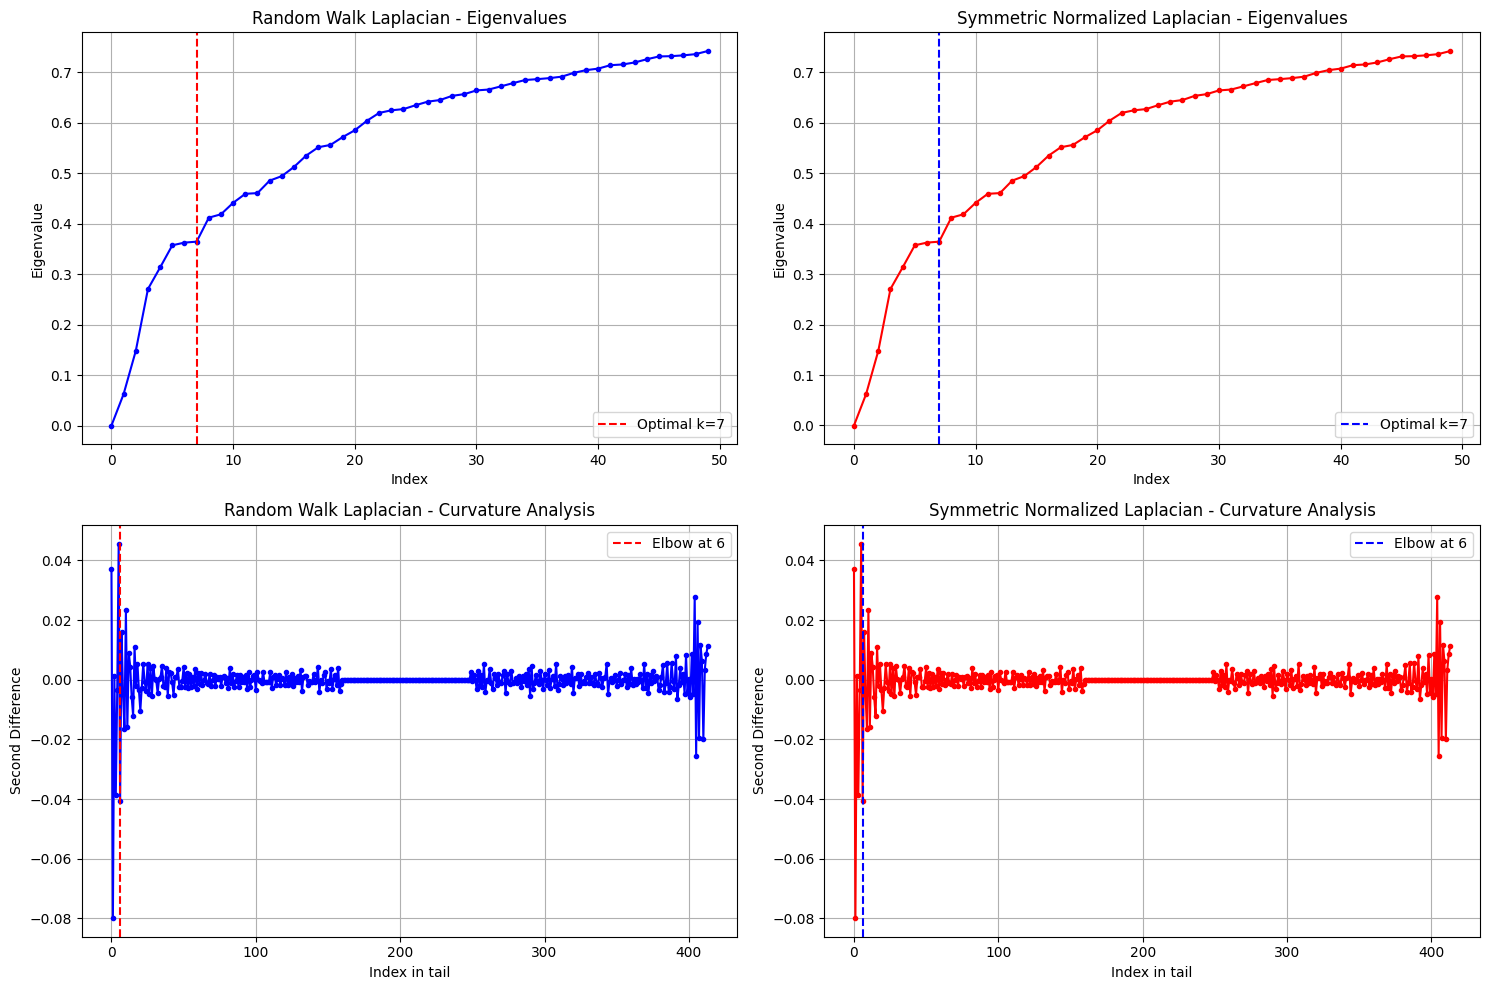

In [10]:
# Find optimal k values using curvature method
k_rw, k_sym, eigenvals_rw, eigenvals_sym, debug_rw, debug_sym = find_optimal_k_curvature(W)

print(f"Optimal k for Random Walk Laplacian: {k_rw}")
print(f"Optimal k for Symmetric Normalized Laplacian: {k_sym}")
print(f"Number of connected components (RW): {debug_rw['start']}")
print(f"Number of connected components (SYM): {debug_sym['start']}")

# Plot eigenvalues and curvature analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot eigenvalues
ax1.plot(eigenvals_rw[:50], 'bo-', markersize=3)
ax1.axvline(x=k_rw, color='red', linestyle='--', label=f'Optimal k={k_rw}')
ax1.set_xlabel('Index')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Random Walk Laplacian - Eigenvalues')
ax1.legend()
ax1.grid(True)

ax2.plot(eigenvals_sym[:50], 'ro-', markersize=3)
ax2.axvline(x=k_sym, color='blue', linestyle='--', label=f'Optimal k={k_sym}')
ax2.set_xlabel('Index')
ax2.set_ylabel('Eigenvalue')
ax2.set_title('Symmetric Normalized Laplacian - Eigenvalues')
ax2.legend()
ax2.grid(True)

# Plot second differences (curvature)
if 'second_diff' in debug_rw:
    ax3.plot(debug_rw['second_diff'], 'bo-', markersize=3)
    ax3.axvline(x=debug_rw['elbow_in_tail'], color='red', linestyle='--', label=f'Elbow at {debug_rw["elbow_in_tail"]}')
    ax3.set_xlabel('Index in tail')
    ax3.set_ylabel('Second Difference')
    ax3.set_title('Random Walk Laplacian - Curvature Analysis')
    ax3.legend()
    ax3.grid(True)

if 'second_diff' in debug_sym:
    ax4.plot(debug_sym['second_diff'], 'ro-', markersize=3)
    ax4.axvline(x=debug_sym['elbow_in_tail'], color='blue', linestyle='--', label=f'Elbow at {debug_sym["elbow_in_tail"]}')
    ax4.set_xlabel('Index in tail')
    ax4.set_ylabel('Second Difference')
    ax4.set_title('Symmetric Normalized Laplacian - Curvature Analysis')
    ax4.legend()
    ax4.grid(True)

plt.tight_layout()
plt.show()


## Apply Both Algorithms with Optimal K


C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


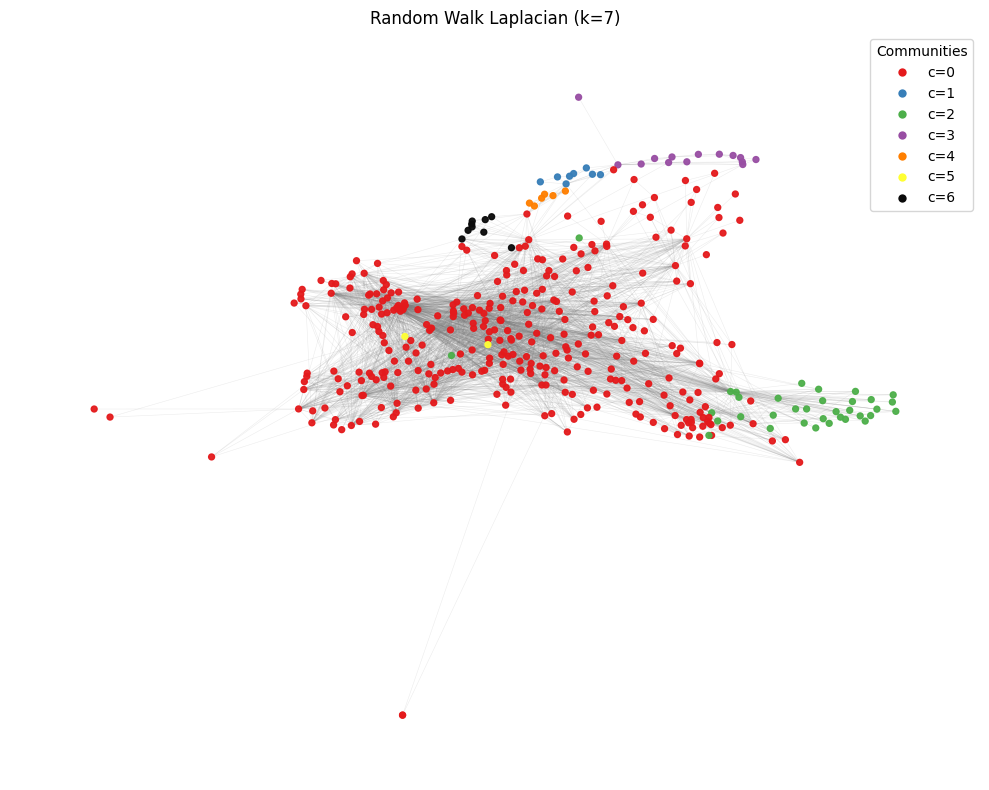

Community sizes for Algorithm 1:
  Community 1: 343 nodes
  Community 2: 8 nodes
  Community 3: 35 nodes
  Community 4: 14 nodes
  Community 5: 6 nodes
  Community 6: 2 nodes
  Community 7: 9 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


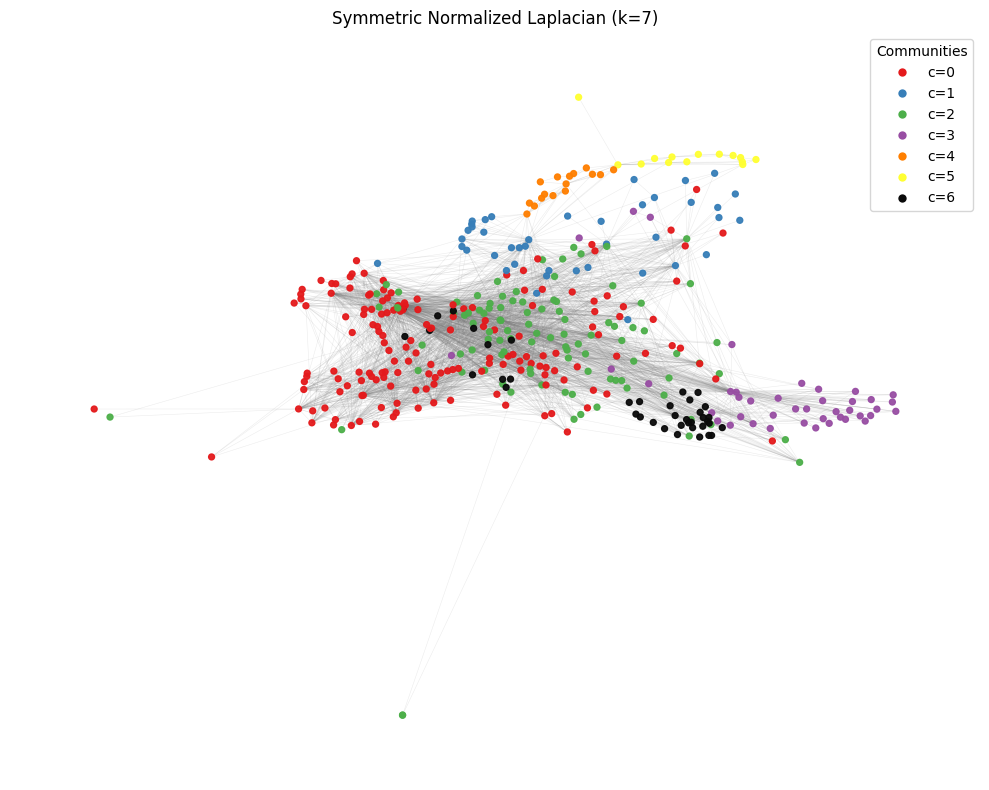

Community sizes for Algorithm 2:
  Community 1: 163 nodes
  Community 2: 41 nodes
  Community 3: 101 nodes
  Community 4: 42 nodes
  Community 5: 16 nodes
  Community 6: 14 nodes
  Community 7: 40 nodes



In [11]:
# Apply Algorithm 1: Random Walk Laplacian
communities_rw, eigenvals_rw_selected, U_rw = random_walk_spectral_clustering(W, k_rw)
visualize_communities_with_plot(G, communities_rw, node_pos, f"Random Walk Laplacian (k={k_rw})", "Algorithm 1")

# Apply Algorithm 2: Symmetric Normalized Laplacian
communities_sym, eigenvals_sym_selected, U_sym, Y_sym = symmetric_normalized_spectral_clustering(W, k_sym)
visualize_communities_with_plot(G, communities_sym, node_pos, f"Symmetric Normalized Laplacian (k={k_sym})", "Algorithm 2")


## Test with K-1 and K+1 Values

As requested, we'll also test the algorithms with k-1 and k+1 values


=== Testing Algorithm 1 (Random Walk Laplacian) with k-1 and k+1 ===


C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


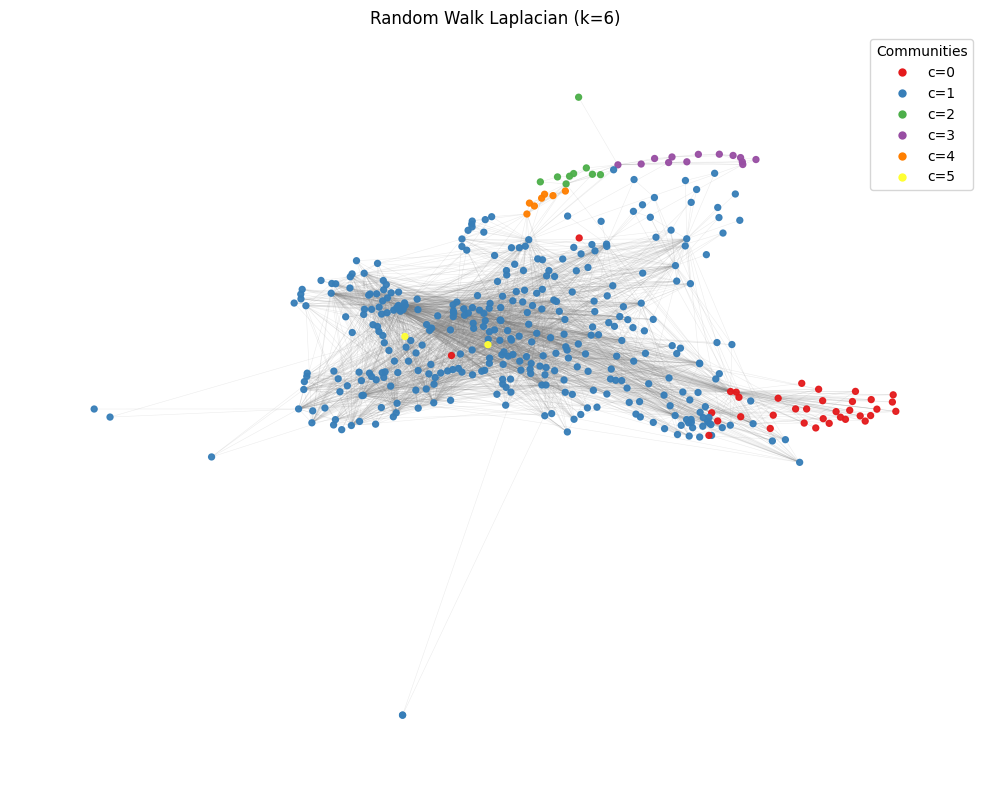

Community sizes for Algorithm 1 (k-1):
  Community 1: 35 nodes
  Community 2: 351 nodes
  Community 3: 9 nodes
  Community 4: 13 nodes
  Community 5: 7 nodes
  Community 6: 2 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


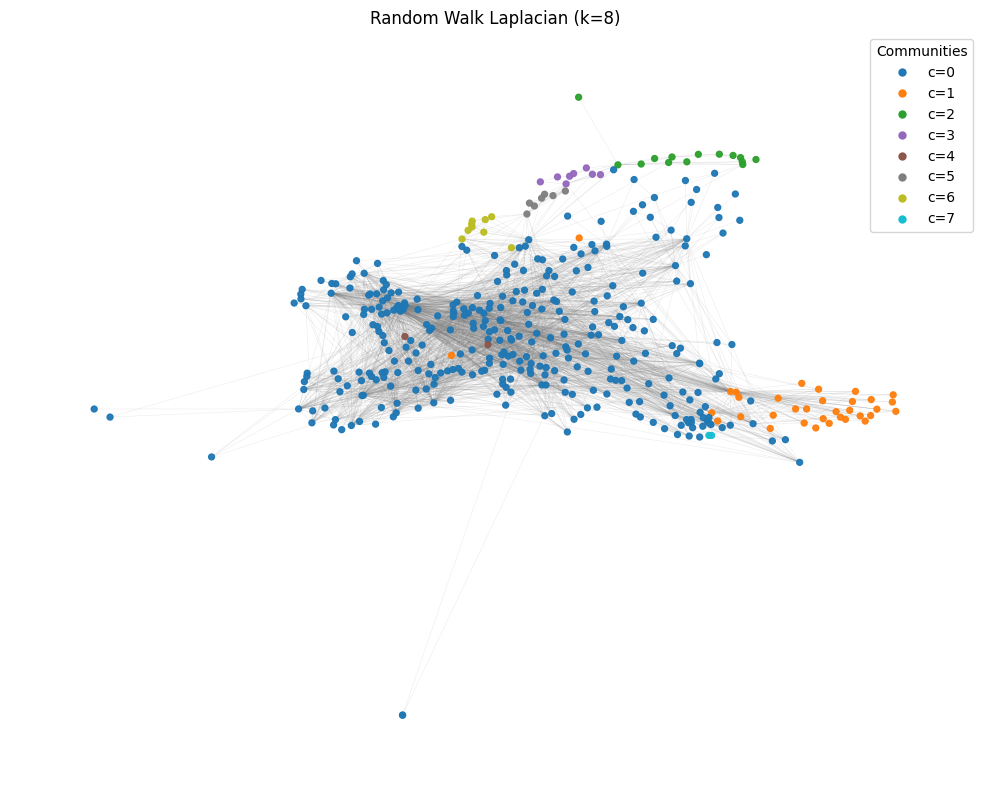

Community sizes for Algorithm 1 (k+1):
  Community 1: 341 nodes
  Community 2: 34 nodes
  Community 3: 14 nodes
  Community 4: 8 nodes
  Community 5: 2 nodes
  Community 6: 7 nodes
  Community 7: 9 nodes
  Community 8: 2 nodes



In [12]:
# Test Algorithm 1 with k-1 and k+1
print("=== Testing Algorithm 1 (Random Walk Laplacian) with k-1 and k+1 ===")

if k_rw > 1:
    communities_rw_k_minus_1, _, _ = random_walk_spectral_clustering(W, k_rw-1)
    visualize_communities_with_plot(G, communities_rw_k_minus_1, node_pos, f"Random Walk Laplacian (k={k_rw-1})", "Algorithm 1 (k-1)")

communities_rw_k_plus_1, _, _ = random_walk_spectral_clustering(W, k_rw+1)
visualize_communities_with_plot(G, communities_rw_k_plus_1, node_pos, f"Random Walk Laplacian (k={k_rw+1})", "Algorithm 1 (k+1)")


=== Testing Algorithm 2 (Symmetric Normalized Laplacian) with k-1 and k+1 ===


C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


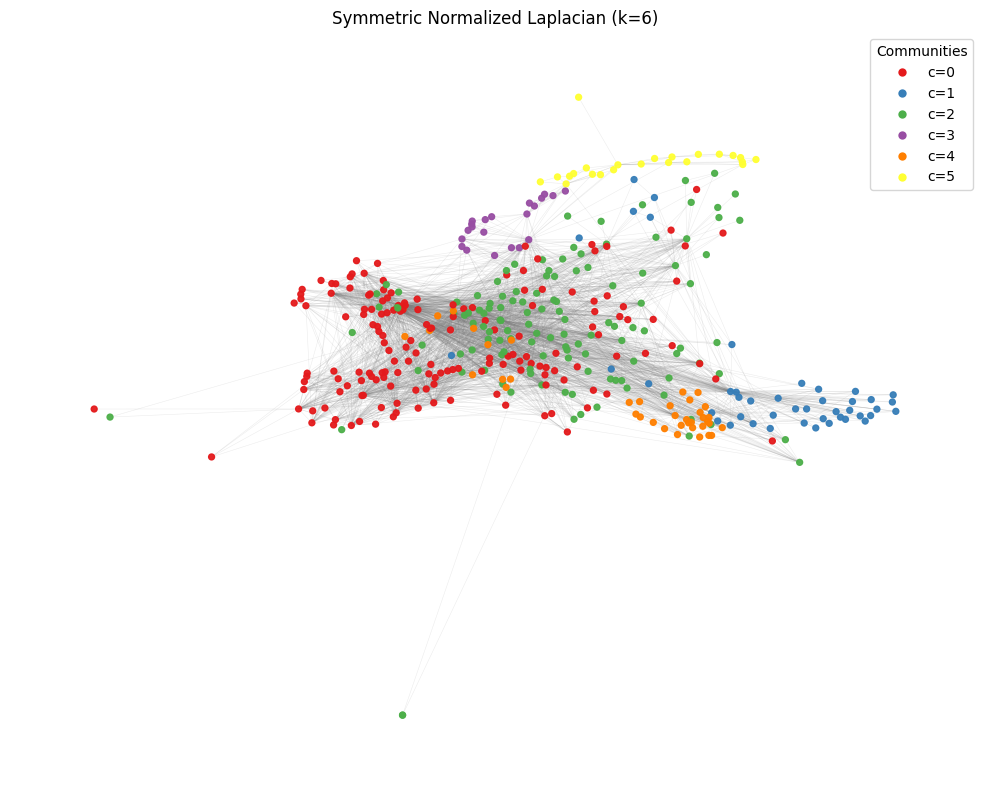

Community sizes for Algorithm 2 (k-1):
  Community 1: 163 nodes
  Community 2: 44 nodes
  Community 3: 126 nodes
  Community 4: 21 nodes
  Community 5: 40 nodes
  Community 6: 23 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


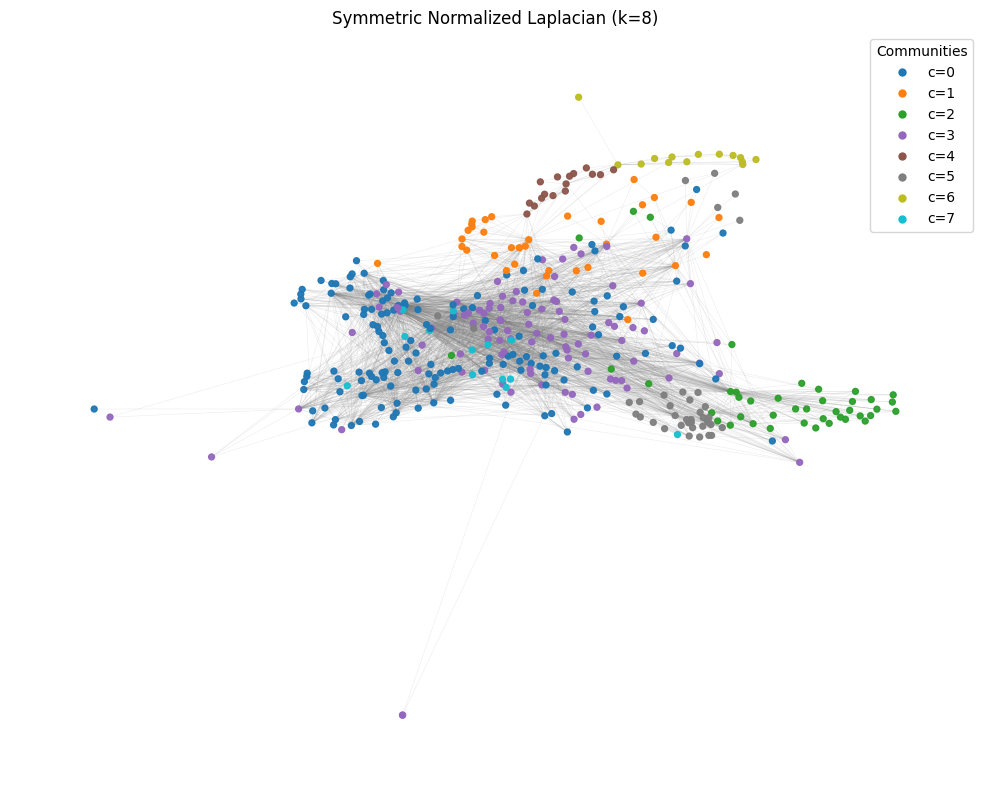

Community sizes for Algorithm 2 (k+1):
  Community 1: 156 nodes
  Community 2: 36 nodes
  Community 3: 42 nodes
  Community 4: 101 nodes
  Community 5: 16 nodes
  Community 6: 38 nodes
  Community 7: 14 nodes
  Community 8: 14 nodes



In [13]:
# Test Algorithm 2 with k-1 and k+1
print("=== Testing Algorithm 2 (Symmetric Normalized Laplacian) with k-1 and k+1 ===")

if k_sym > 1:
    communities_sym_k_minus_1, _, _, _ = symmetric_normalized_spectral_clustering(W, k_sym-1)
    visualize_communities_with_plot(G, communities_sym_k_minus_1, node_pos, f"Symmetric Normalized Laplacian (k={k_sym-1})", "Algorithm 2 (k-1)")

communities_sym_k_plus_1, _, _, _ = symmetric_normalized_spectral_clustering(W, k_sym+1)
visualize_communities_with_plot(G, communities_sym_k_plus_1, node_pos, f"Symmetric Normalized Laplacian (k={k_sym+1})", "Algorithm 2 (k+1)")


## Force-Directed Visualizations

Now let's visualize all our clustering results using force-directed layouts to better see how well the communities are separated in a more natural network layout.


=== Force-Directed Visualizations of Main Results ===
Random Walk Laplacian (k=7) - Force-Directed Layout:


C:\Users\thano\AppData\Local\Temp\ipykernel_34676\208593240.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


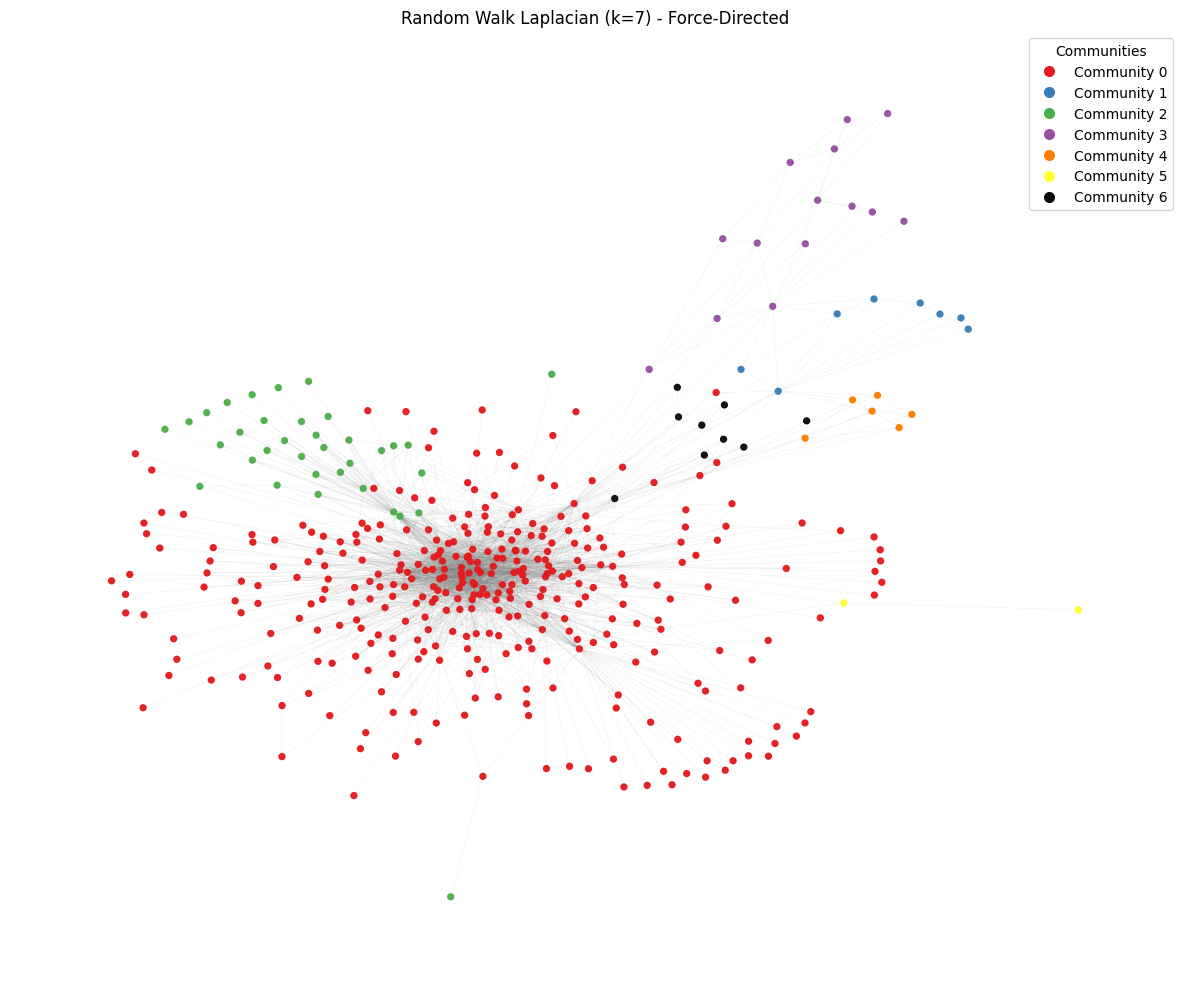

Community sizes for Algorithm 1:
  Community 1: 343 nodes
  Community 2: 8 nodes
  Community 3: 35 nodes
  Community 4: 14 nodes
  Community 5: 6 nodes
  Community 6: 2 nodes
  Community 7: 9 nodes

Symmetric Normalized Laplacian (k=7) - Force-Directed Layout:


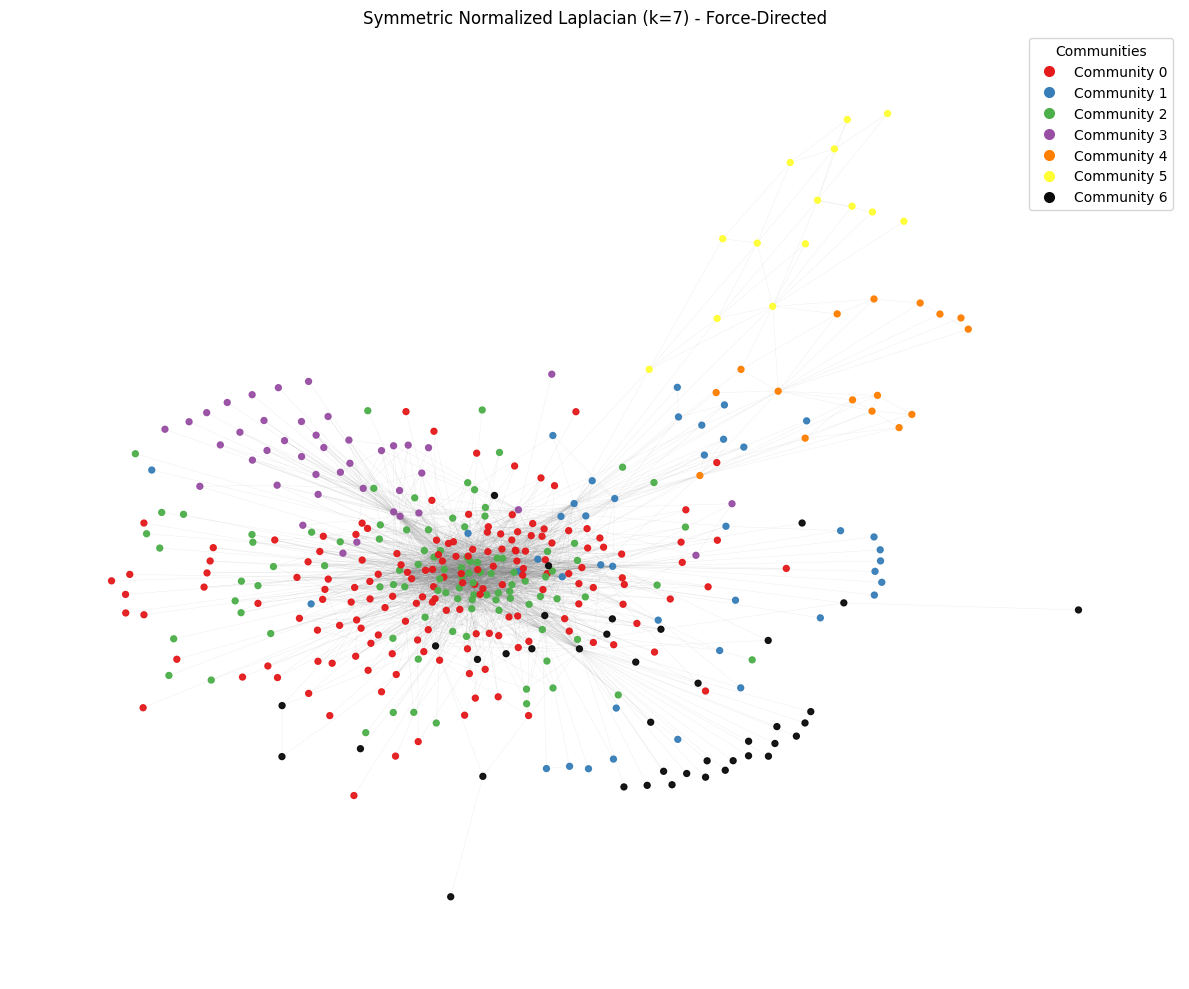

Community sizes for Algorithm 2:
  Community 1: 163 nodes
  Community 2: 41 nodes
  Community 3: 101 nodes
  Community 4: 42 nodes
  Community 5: 16 nodes
  Community 6: 14 nodes
  Community 7: 40 nodes



In [14]:
# Force-directed visualization of main results
print("=== Force-Directed Visualizations of Main Results ===")

# Algorithm 1: Random Walk Laplacian (optimal k)
print("Random Walk Laplacian (k={}) - Force-Directed Layout:".format(k_rw))
visualize_communities_force_directed(G, communities_rw, f"Random Walk Laplacian (k={k_rw}) - Force-Directed", "Algorithm 1")

# Algorithm 2: Symmetric Normalized Laplacian (optimal k)
print("Symmetric Normalized Laplacian (k={}) - Force-Directed Layout:".format(k_sym))
visualize_communities_force_directed(G, communities_sym, f"Symmetric Normalized Laplacian (k={k_sym}) - Force-Directed", "Algorithm 2")


=== Force-Directed Visualizations of K-1 and K+1 Test Cases ===
Random Walk Laplacian (k=6) - Force-Directed Layout:


C:\Users\thano\AppData\Local\Temp\ipykernel_34676\208593240.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


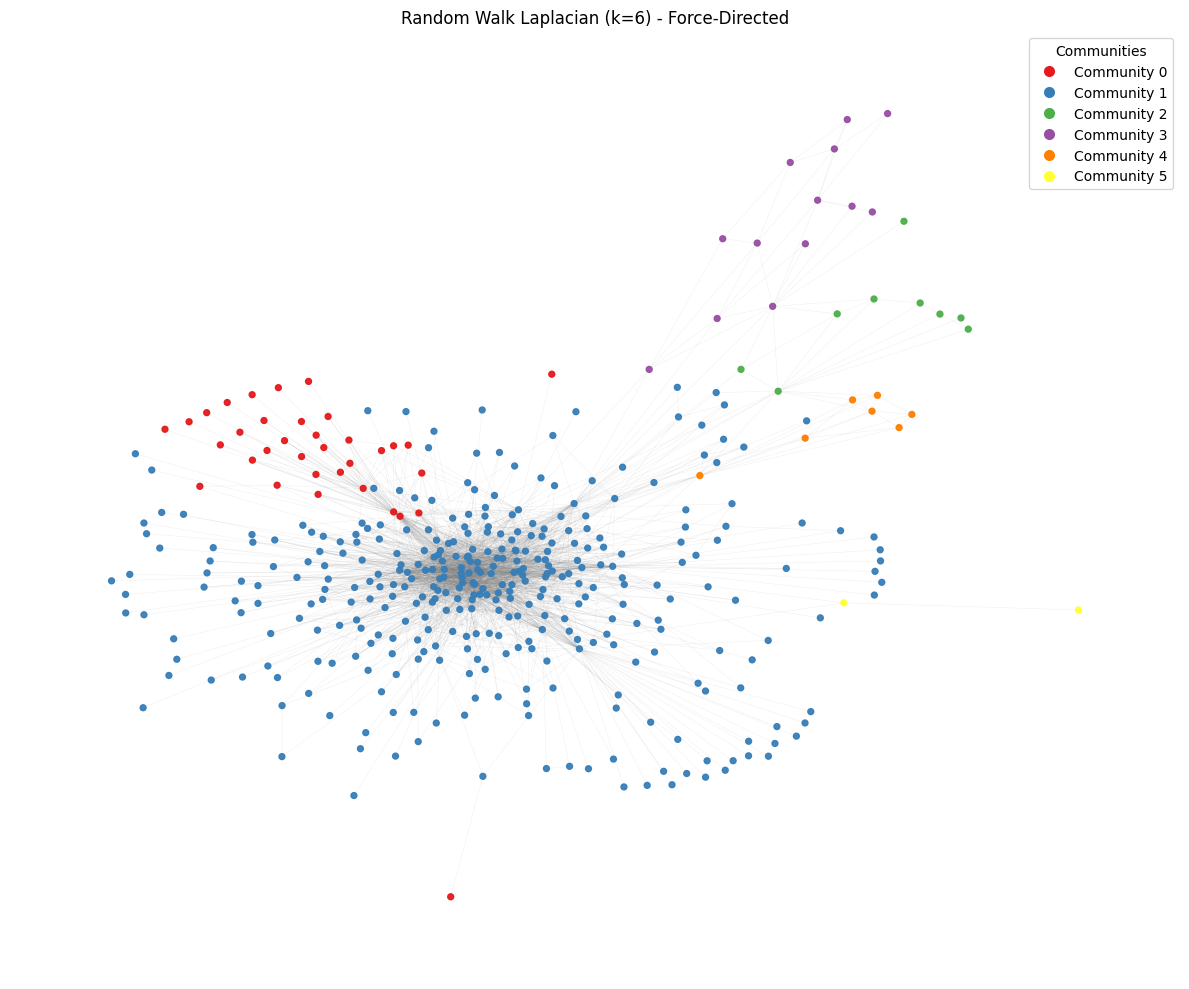

Community sizes for Algorithm 1 (k-1):
  Community 1: 35 nodes
  Community 2: 351 nodes
  Community 3: 9 nodes
  Community 4: 13 nodes
  Community 5: 7 nodes
  Community 6: 2 nodes

Random Walk Laplacian (k=8) - Force-Directed Layout:


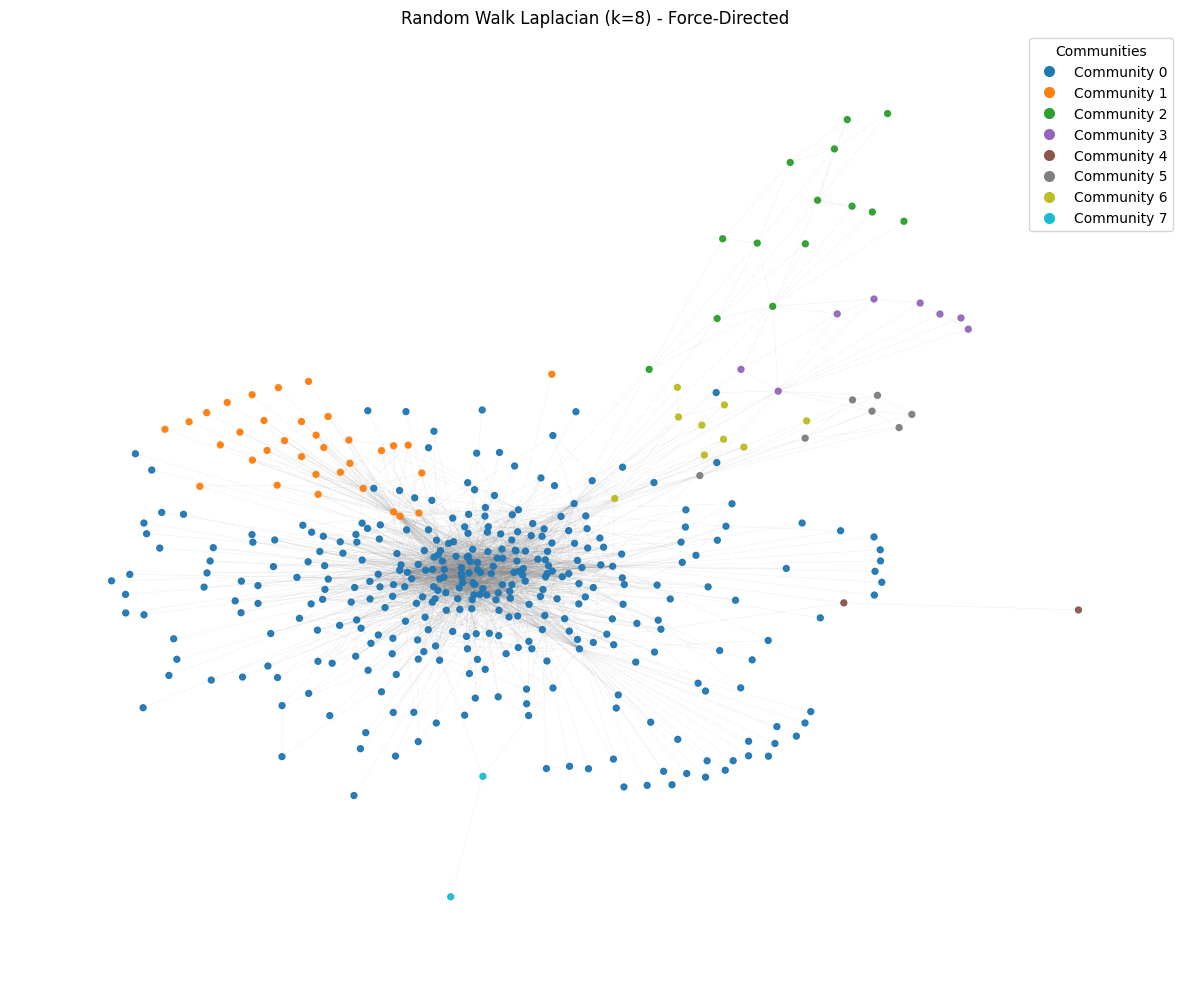

Community sizes for Algorithm 1 (k+1):
  Community 1: 341 nodes
  Community 2: 34 nodes
  Community 3: 14 nodes
  Community 4: 8 nodes
  Community 5: 2 nodes
  Community 6: 7 nodes
  Community 7: 9 nodes
  Community 8: 2 nodes

Symmetric Normalized Laplacian (k=6) - Force-Directed Layout:


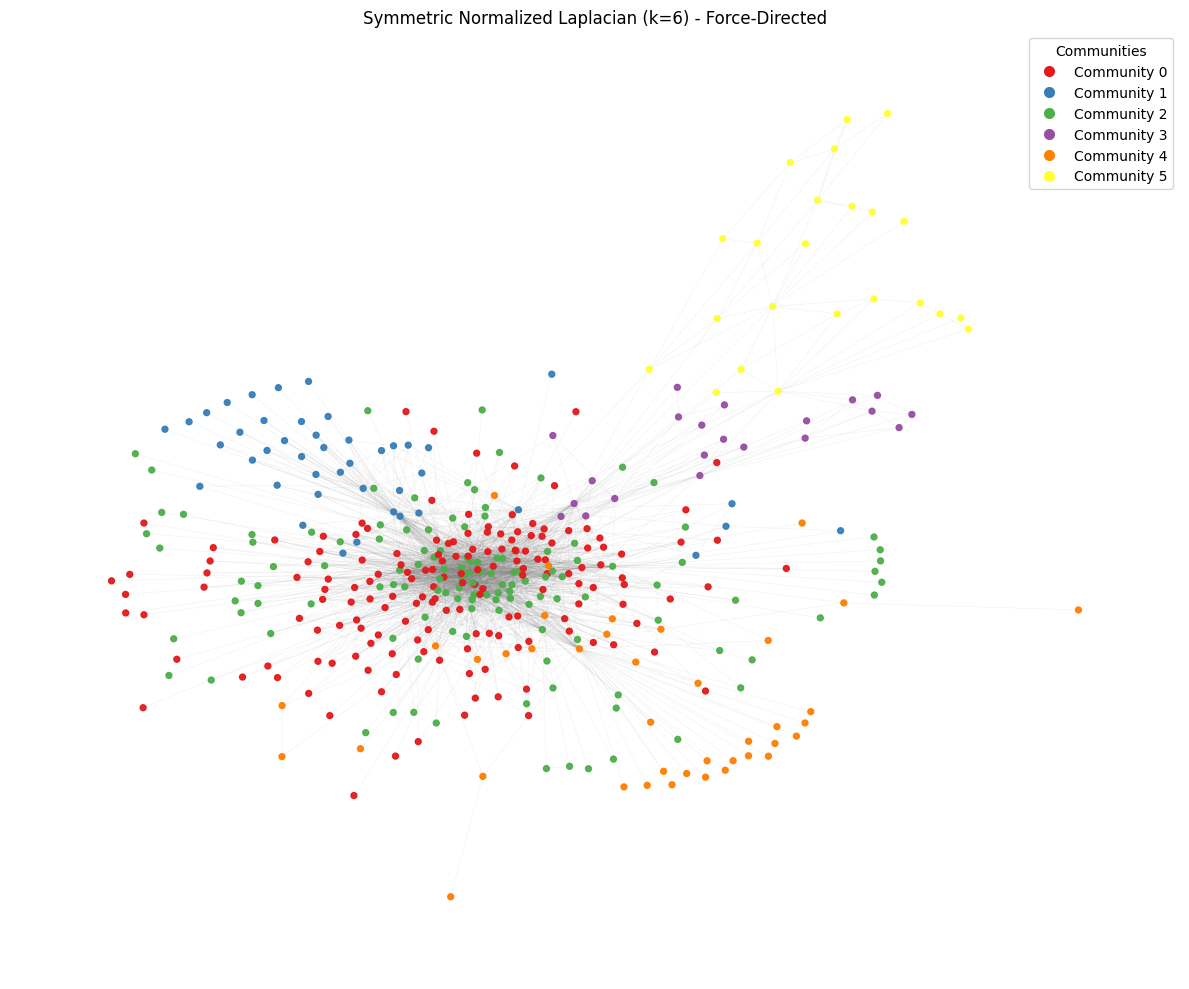

Community sizes for Algorithm 2 (k-1):
  Community 1: 163 nodes
  Community 2: 44 nodes
  Community 3: 126 nodes
  Community 4: 21 nodes
  Community 5: 40 nodes
  Community 6: 23 nodes

Symmetric Normalized Laplacian (k=8) - Force-Directed Layout:


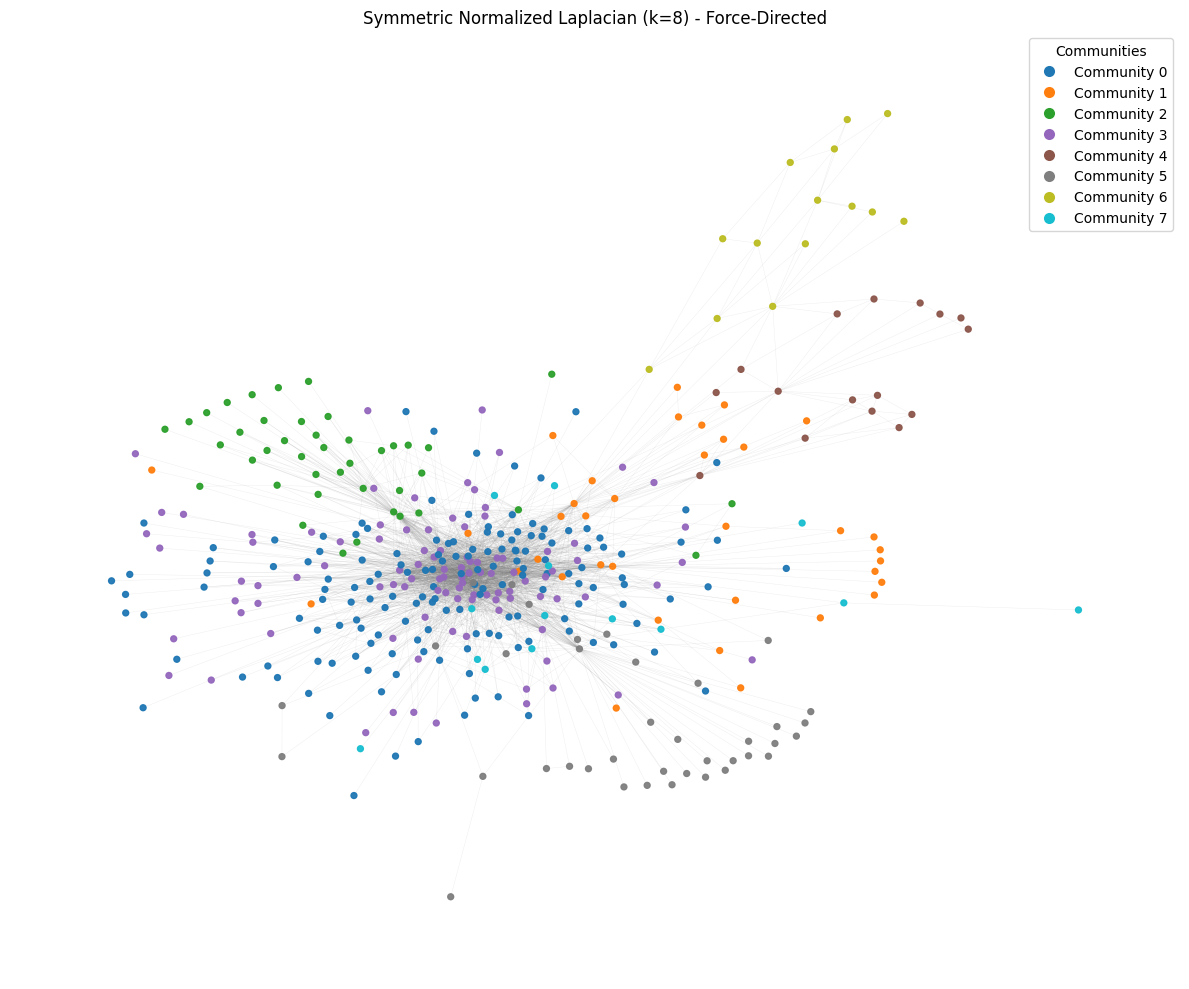

Community sizes for Algorithm 2 (k+1):
  Community 1: 156 nodes
  Community 2: 36 nodes
  Community 3: 42 nodes
  Community 4: 101 nodes
  Community 5: 16 nodes
  Community 6: 38 nodes
  Community 7: 14 nodes
  Community 8: 14 nodes



In [15]:
# Force-directed visualization of k-1 and k+1 test cases
print("=== Force-Directed Visualizations of K-1 and K+1 Test Cases ===")

# Algorithm 1: k-1 and k+1 cases
if k_rw > 1:
    print("Random Walk Laplacian (k={}) - Force-Directed Layout:".format(k_rw-1))
    visualize_communities_force_directed(G, communities_rw_k_minus_1, f"Random Walk Laplacian (k={k_rw-1}) - Force-Directed", "Algorithm 1 (k-1)")

print("Random Walk Laplacian (k={}) - Force-Directed Layout:".format(k_rw+1))
visualize_communities_force_directed(G, communities_rw_k_plus_1, f"Random Walk Laplacian (k={k_rw+1}) - Force-Directed", "Algorithm 1 (k+1)")

# Algorithm 2: k-1 and k+1 cases
if k_sym > 1:
    print("Symmetric Normalized Laplacian (k={}) - Force-Directed Layout:".format(k_sym-1))
    visualize_communities_force_directed(G, communities_sym_k_minus_1, f"Symmetric Normalized Laplacian (k={k_sym-1}) - Force-Directed", "Algorithm 2 (k-1)")

print("Symmetric Normalized Laplacian (k={}) - Force-Directed Layout:".format(k_sym+1))
visualize_communities_force_directed(G, communities_sym_k_plus_1, f"Symmetric Normalized Laplacian (k={k_sym+1}) - Force-Directed", "Algorithm 2 (k+1)")


C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


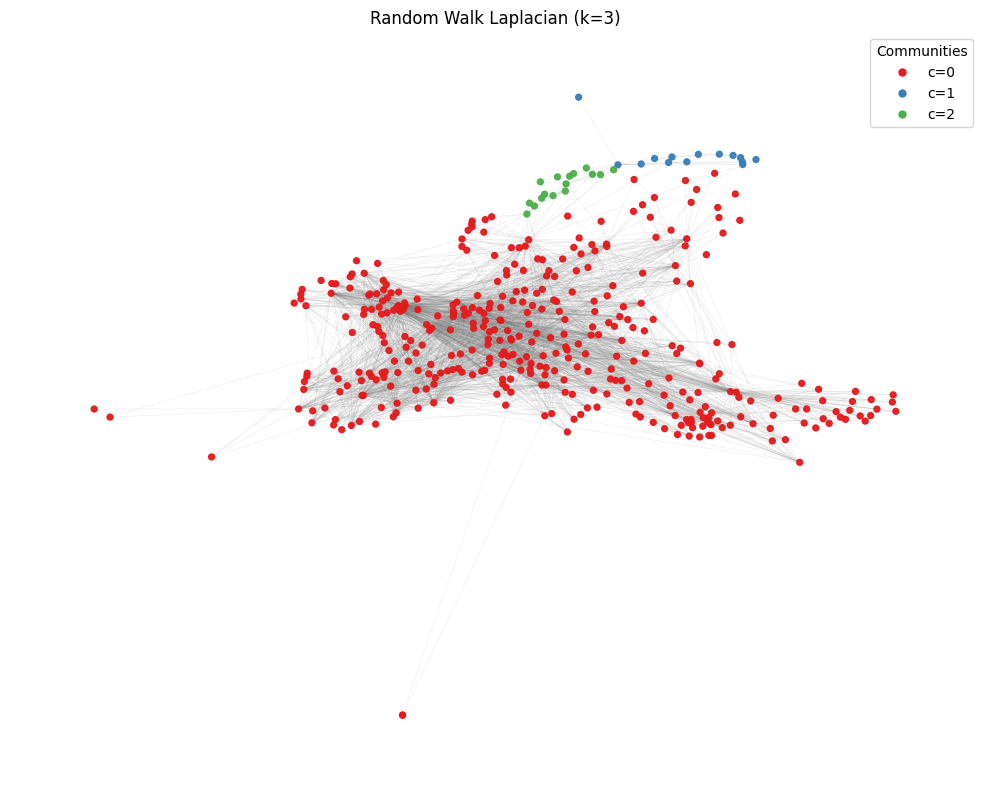

Community sizes for Algorithm 1 (fixed K=3):
  Community 1: 387 nodes
  Community 2: 14 nodes
  Community 3: 16 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\208593240.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


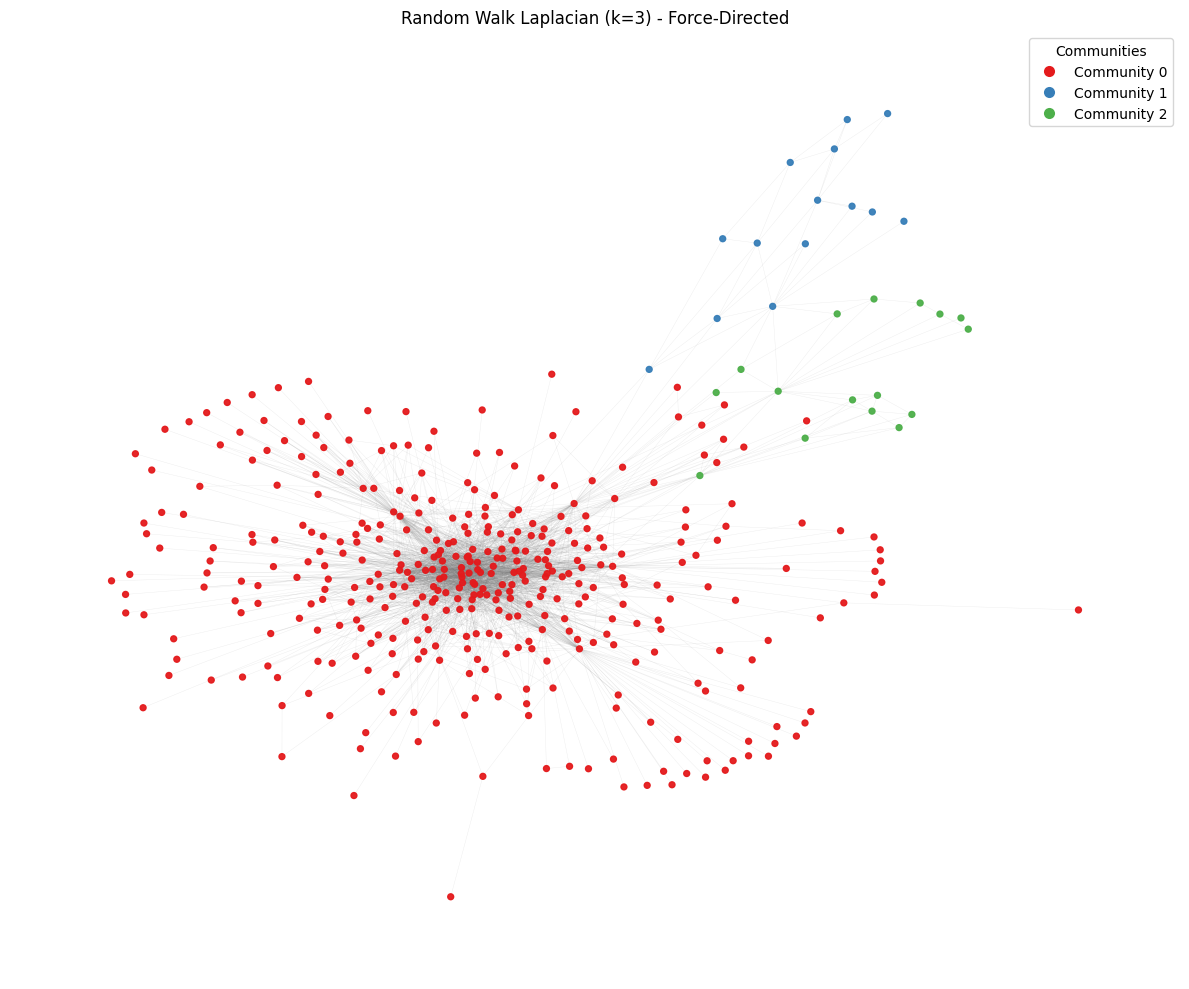

Community sizes for Algorithm 1 (fixed K=3):
  Community 1: 387 nodes
  Community 2: 14 nodes
  Community 3: 16 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


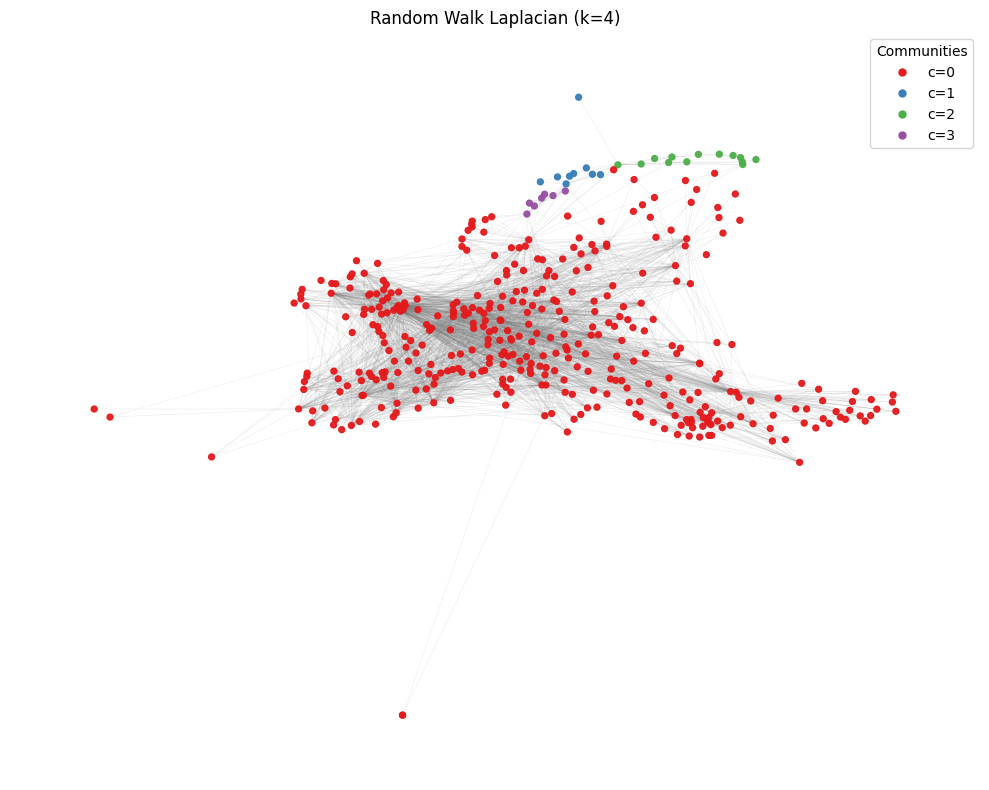

Community sizes for Algorithm 1 (fixed K=4):
  Community 1: 388 nodes
  Community 2: 9 nodes
  Community 3: 13 nodes
  Community 4: 7 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\208593240.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


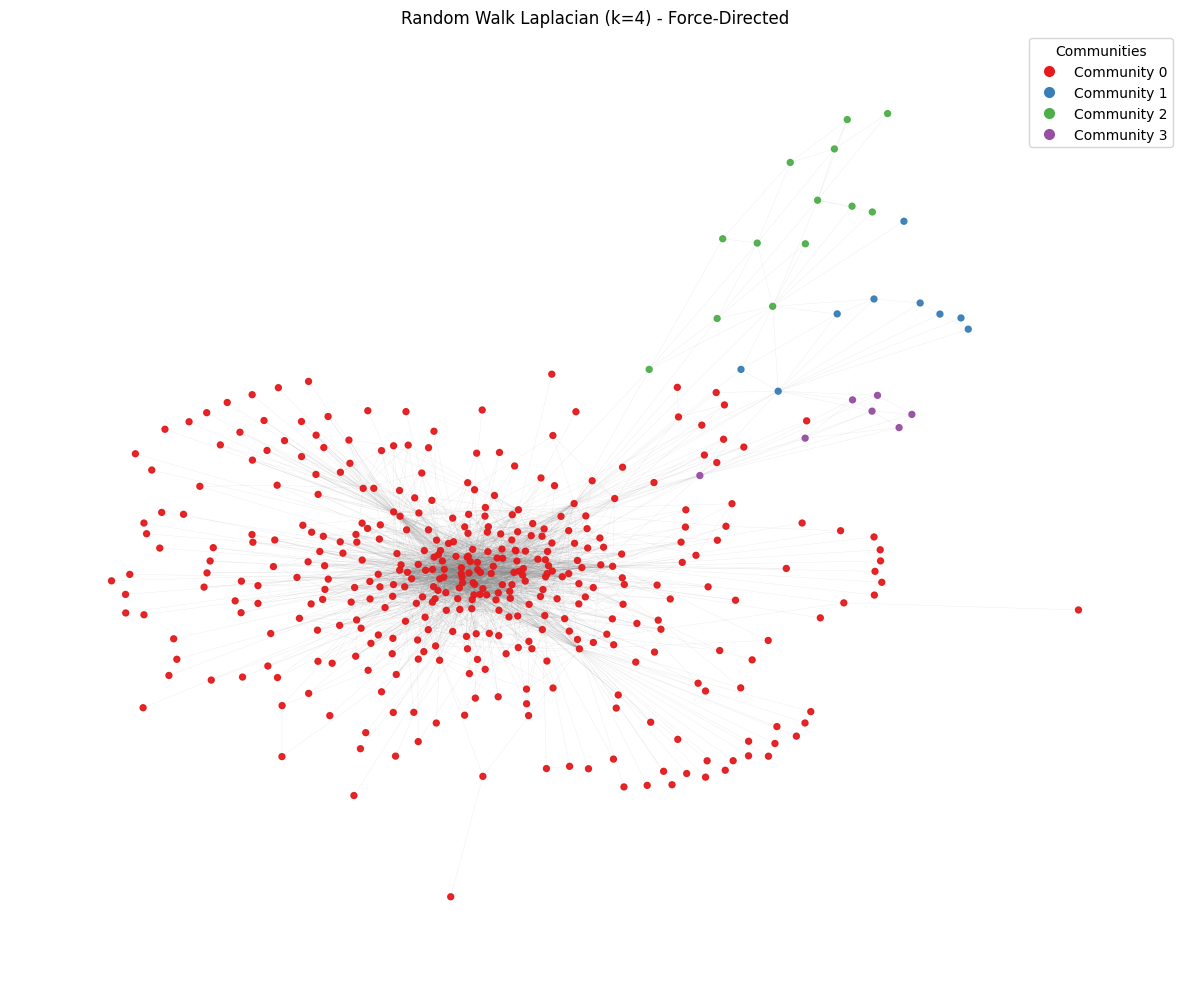

Community sizes for Algorithm 1 (fixed K=4):
  Community 1: 388 nodes
  Community 2: 9 nodes
  Community 3: 13 nodes
  Community 4: 7 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


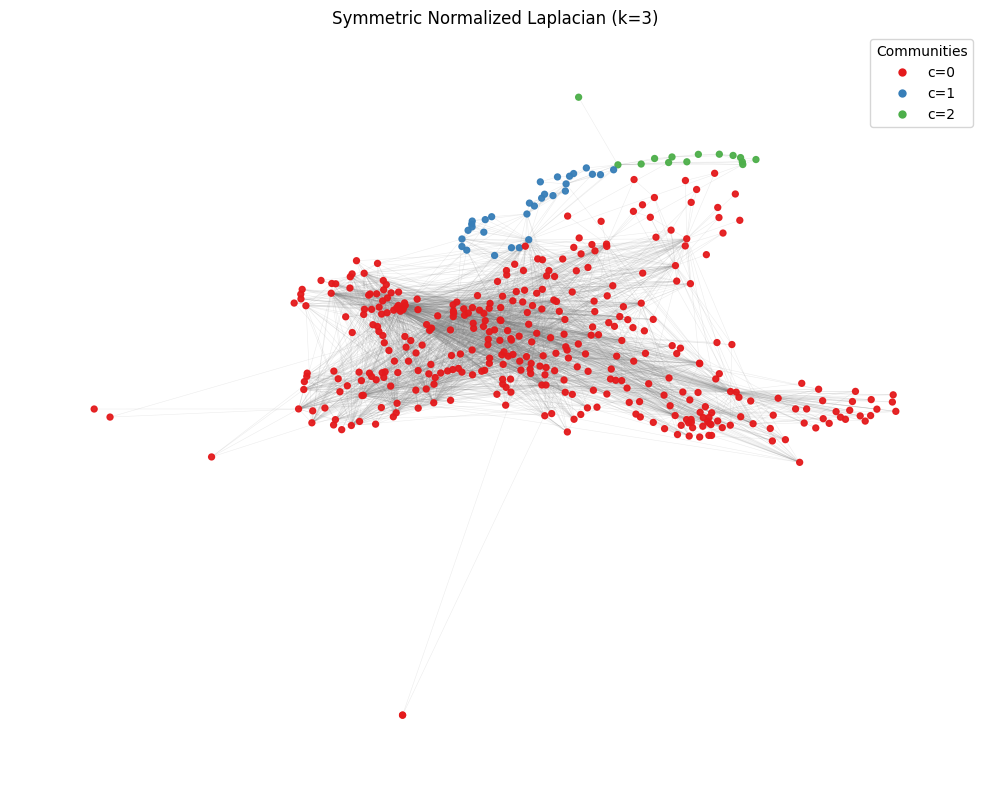

Community sizes for Algorithm 2 (fixed K=3):
  Community 1: 373 nodes
  Community 2: 30 nodes
  Community 3: 14 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\208593240.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


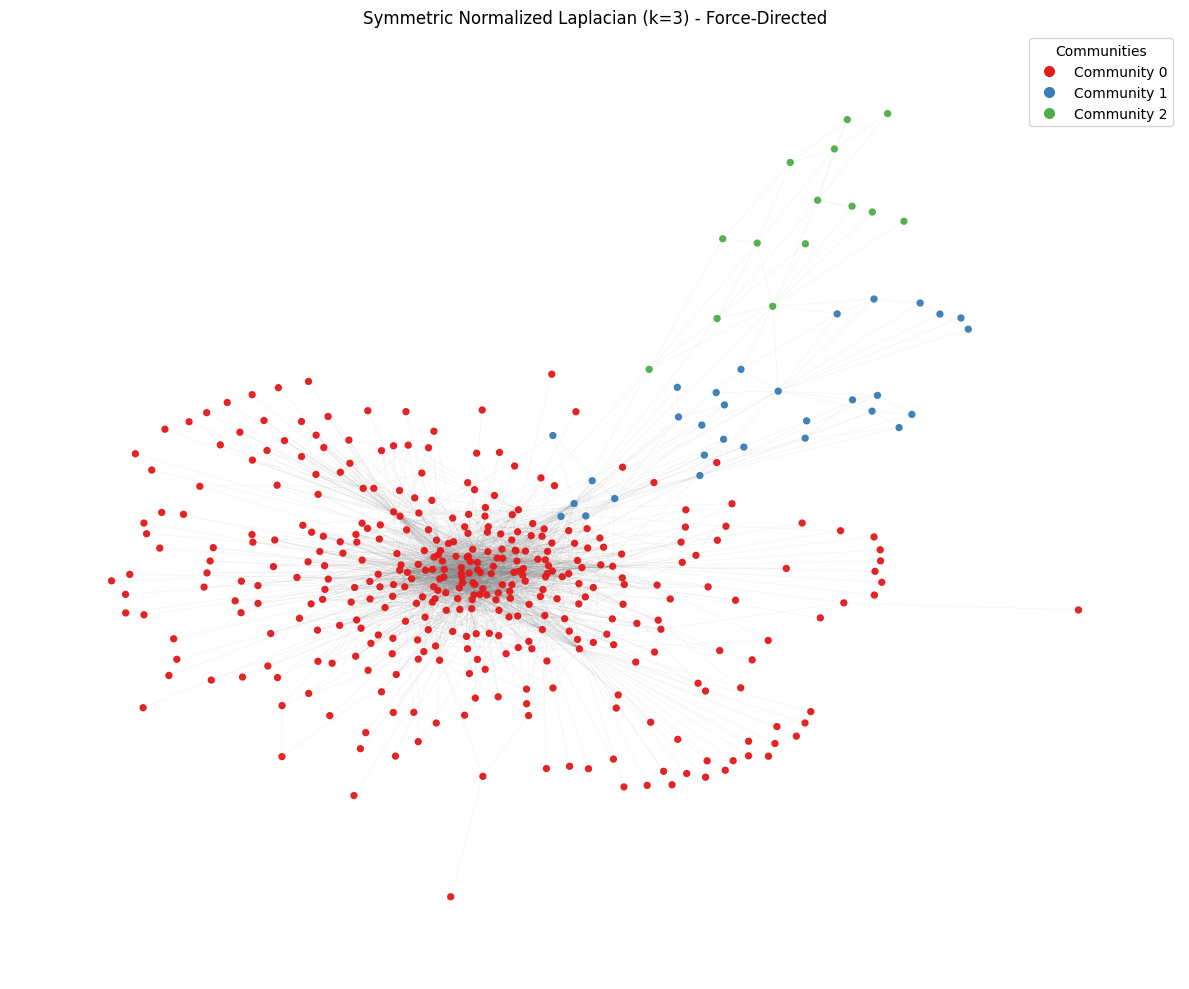

C:\Users\thano\AppData\Local\Temp\ipykernel_34676\2027614550.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


Community sizes for Algorithm 2 (fixed K=3):
  Community 1: 373 nodes
  Community 2: 30 nodes
  Community 3: 14 nodes



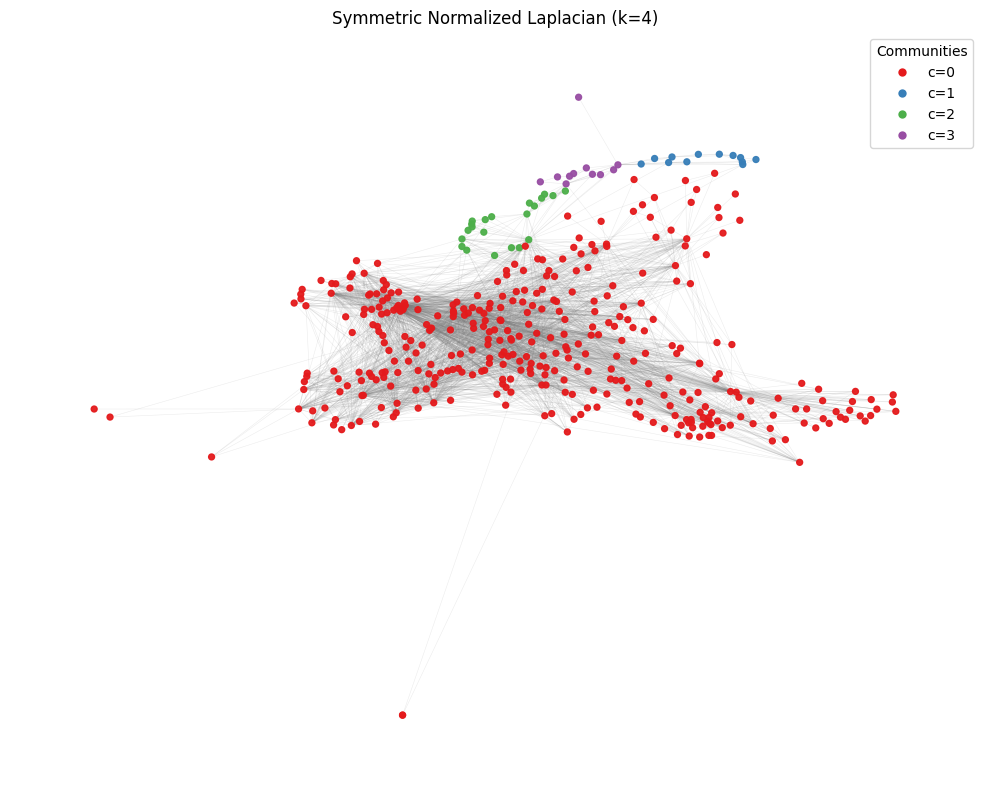

Community sizes for Algorithm 2 (fixed K=4):
  Community 1: 373 nodes
  Community 2: 12 nodes
  Community 3: 21 nodes
  Community 4: 11 nodes



C:\Users\thano\AppData\Local\Temp\ipykernel_34676\208593240.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_comms)))  # fallback


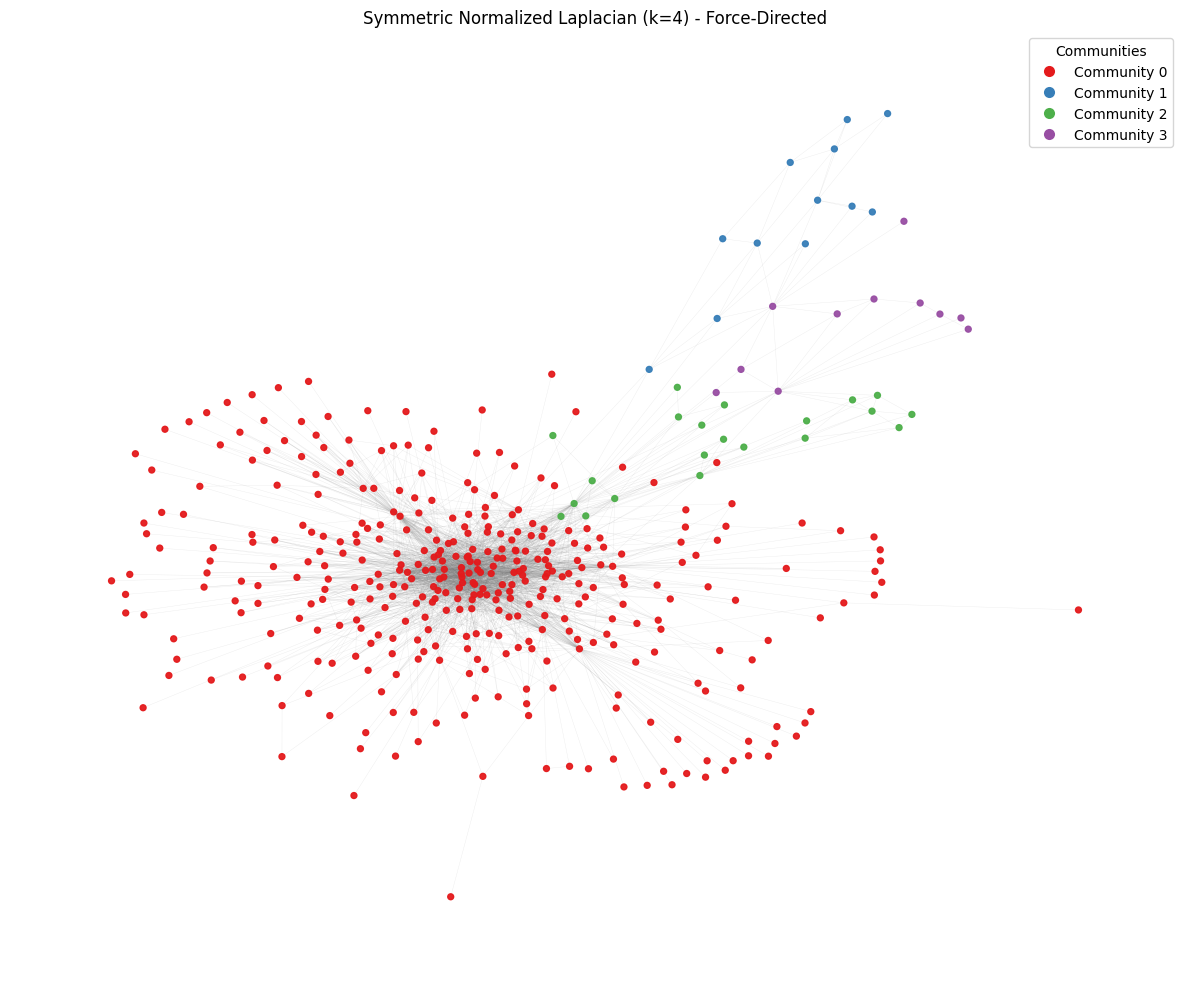

Community sizes for Algorithm 2 (fixed K=4):
  Community 1: 373 nodes
  Community 2: 12 nodes
  Community 3: 21 nodes
  Community 4: 11 nodes



In [16]:
#Testing with fixed K values 3 and 4

# Apply Algorithm 1: Random Walk Laplacian with K=3
communities_rw_3, eigenvals_rw_3, U_rw_3 = random_walk_spectral_clustering(W, 3)
visualize_communities_with_plot(G, communities_rw_3, node_pos, f"Random Walk Laplacian (k=3)", "Algorithm 1 (fixed K=3)")
#force directed
visualize_communities_force_directed(G, communities_rw_3, f"Random Walk Laplacian (k=3) - Force-Directed", "Algorithm 1 (fixed K=3)")
    
#now the same for k=4
communities_rw_4, eigenvals_rw_4, U_rw_4 = random_walk_spectral_clustering(W, 4)
visualize_communities_with_plot(G, communities_rw_4, node_pos, f"Random Walk Laplacian (k=4)", "Algorithm 1 (fixed K=4)")
visualize_communities_force_directed(G, communities_rw_4, f"Random Walk Laplacian (k=4) - Force-Directed", "Algorithm 1 (fixed K=4)")

# Apply Algorithm 2: Symmetric Normalized Laplacian with K=3
communities_sym_3, eigenvals_sym_3, U_sym_3, Y_sym_3 = symmetric_normalized_spectral_clustering(W, 3)
visualize_communities_with_plot(G, communities_sym_3, node_pos, f"Symmetric Normalized Laplacian (k=3)", "Algorithm 2 (fixed K=3)")
visualize_communities_force_directed(G, communities_sym_3, f"Symmetric Normalized Laplacian (k=3) - Force-Directed", "Algorithm 2 (fixed K=3)")

#now the same for k=4
communities_sym_4, eigenvals_sym_4, U_sym_4, Y_sym_4 = symmetric_normalized_spectral_clustering(W, 4)
visualize_communities_with_plot(G, communities_sym_4, node_pos, f"Symmetric Normalized Laplacian (k=4)", "Algorithm 2 (fixed K=4)")
visualize_communities_force_directed(G, communities_sym_4, f"Symmetric Normalized Laplacian (k=4) - Force-Directed", "Algorithm 2 (fixed K=4)")